# K-Means и K-Means++ на рукописных цифрах

**Датасет:** `sklearn.datasets.load_digits` — **1797 изображений** рукописных цифр 0–9, каждое **8×8 пикселей** (64 признака).

**Почему это интересно:**
- K-Means работает в 64-мерном пространстве — и всё равно находит цифры!
- Центроиды можно визуализировать как **усреднённые изображения**
- Это задача **без учителя**: алгоритм не видит меток. Мы используем метки только в конце, чтобы проверить — угадал ли он.

---

## 1. Краткая теория

**K-Means** — алгоритм кластеризации, разбивающий данные на K групп путём итеративного обновления центроидов. **K-Means++** улучшает инициализацию, выбирая начальные центроиды максимально удалёнными друг от друга. Подробная теория — в [README.md](README.md).

## 2. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
np.random.seed(42)

## 3. Первичный анализ

In [2]:
digits = load_digits()
X = digits.data        # (1797, 64) — каждая строка = картинка, вытянутая в вектор
y_true = digits.target  # метки 0–9 (для проверки в конце, K-Means их НЕ увидит)

print(f"Размер: {X.shape[0]} изображений × {X.shape[1]} признаков (пикселей)")
print(f"Классы: {sorted(np.unique(y_true))}")
print(f"Распределение: {dict(zip(*np.unique(y_true, return_counts=True)))}")
print(f"Значения пикселей: от {X.min():.0f} до {X.max():.0f}")

Размер: 1797 изображений × 64 признаков (пикселей)
Классы: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Распределение: {np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}
Значения пикселей: от 0 до 16


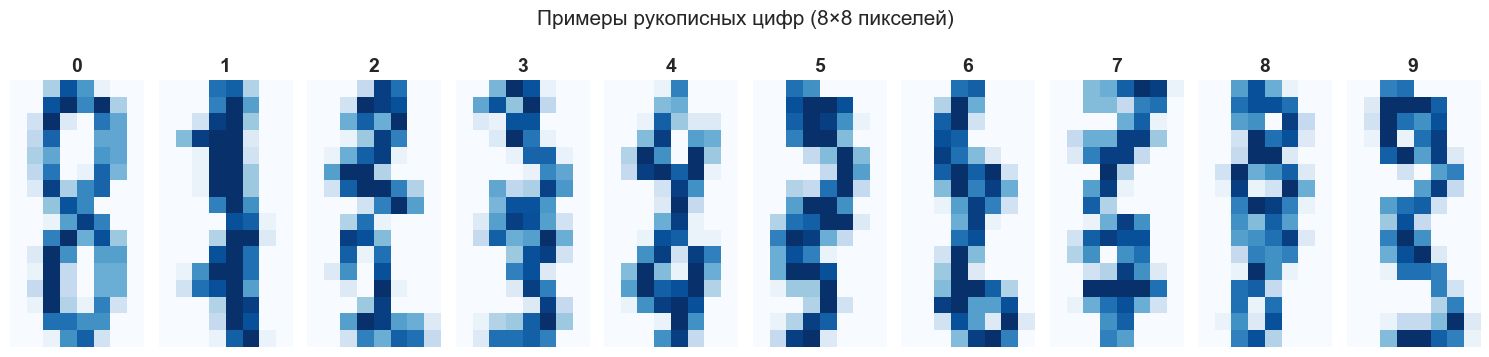

In [3]:
# Примеры каждой цифры
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for digit in range(10):
    idxs = np.where(y_true == digit)[0]
    for row in range(2):
        axes[row, digit].imshow(X[idxs[row]].reshape(8, 8), cmap='Blues', interpolation='nearest')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=14, fontweight='bold')

plt.suptitle('Примеры рукописных цифр (8×8 пикселей)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 4. Предобработка

### Стандартизация

K-Means считает **евклидово расстояние** между точками. Если один признак в диапазоне 0–1000, а другой 0–1, то первый будет полностью доминировать. `StandardScaler` приводит все признаки к среднему = 0 и стандартному отклонению = 1.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"До:    mean={X.mean():.2f},  std={X.std():.2f}")
print(f"После: mean={X_scaled.mean():.6f},  std={X_scaled.std():.4f}")
print("\nТеперь все 64 пикселя «равноправны» по масштабу.")

До:    mean=4.88,  std=6.02
После: mean=0.000000,  std=0.9763

Теперь все 64 пикселя «равноправны» по масштабу.


### Снижение размерности (PCA + t-SNE)

**Проблема:** у нас 64 признака (пикселя). Человек не может визуализировать 64 измерения — максимум 2–3.

**Решение:** «сжать» 64 признака в 2 для визуализации. При этом K-Means будет работать на **исходных 64 признаках** — снижение размерности нужно **только для картинок**.

In [5]:
# PCA — линейное снижение
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# t-SNE — нелинейное снижение
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

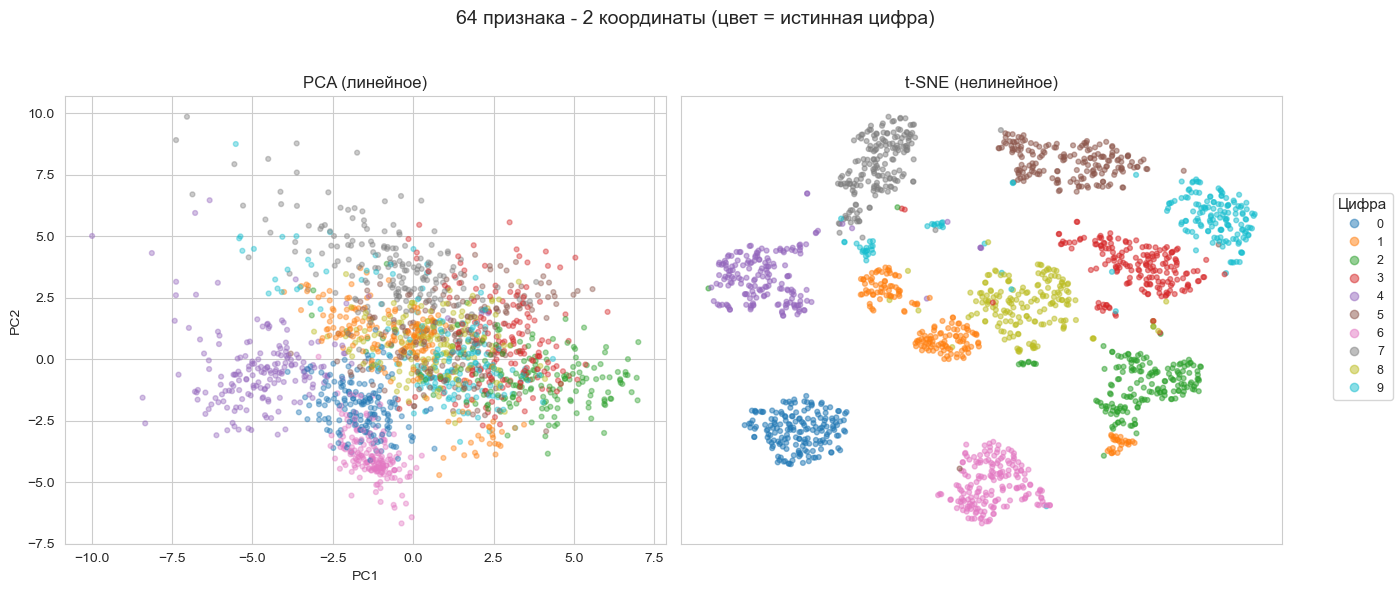

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='tab10', alpha=0.4, s=12)
axes[0].set_title(f'PCA (линейное)', fontsize=12)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# t-SNE
sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='tab10', alpha=0.5, s=12)
axes[1].set_title('t-SNE (нелинейное)', fontsize=12)
axes[1].set_xticks([]); axes[1].set_yticks([])

# Общая легенда
handles, labels = sc2.legend_elements()
fig.legend(handles, [str(i) for i in range(10)], loc='center right',
           title='Цифра', fontsize=9, title_fontsize=11, ncol=1)

plt.suptitle('64 признака - 2 координаты (цвет = истинная цифра)', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()


## 5. Обучение модели

### Подбор числа кластеров K
Две основные метрики:

**WCSS (Within-Cluster Sum of Squares)** — сумма квадратов расстояний от точек до центроида их кластера. Это то, что K-Means минимизирует. Чем меньше — тем компактнее кластеры. Используется в **методе локтя**.

**Silhouette Score** — для каждой точки: насколько она ближе к своему кластеру, чем к ближайшему чужому. От −1 до 1, чем больше — тем лучше.


In [7]:
K_range = range(2, 25)
wcss_vals = []
sil_vals = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss_vals.append(km.inertia_)  # inertia в sklearn = WCSS
    sil_vals.append(silhouette_score(X_scaled, labels))
    print(f"  K={k:2d}   WCSS={km.inertia_:8.1f}   Silhouette={sil_vals[-1]:.4f}")

  K= 2   WCSS=100423.8   Silhouette=0.1056
  K= 3   WCSS= 93842.5   Silhouette=0.1053
  K= 4   WCSS= 89214.0   Silhouette=0.0954
  K= 5   WCSS= 85096.1   Silhouette=0.1023


  K= 6   WCSS= 81678.5   Silhouette=0.0988
  K= 7   WCSS= 77749.3   Silhouette=0.1135
  K= 8   WCSS= 74854.2   Silhouette=0.1266


  K= 9   WCSS= 72029.7   Silhouette=0.1360
  K=10   WCSS= 69813.6   Silhouette=0.1394
  K=11   WCSS= 67261.8   Silhouette=0.1532


  K=12   WCSS= 65031.7   Silhouette=0.1543
  K=13   WCSS= 62763.2   Silhouette=0.1565
  K=14   WCSS= 61963.4   Silhouette=0.1562


  K=15   WCSS= 59534.5   Silhouette=0.1583
  K=16   WCSS= 59448.7   Silhouette=0.1520
  K=17   WCSS= 57038.2   Silhouette=0.1497


  K=18   WCSS= 57000.8   Silhouette=0.1555
  K=19   WCSS= 55043.5   Silhouette=0.1568
  K=20   WCSS= 54100.0   Silhouette=0.1579


  K=21   WCSS= 52256.1   Silhouette=0.1614
  K=22   WCSS= 52149.0   Silhouette=0.1339
  K=23   WCSS= 50465.6   Silhouette=0.1481


  K=24   WCSS= 49361.9   Silhouette=0.1371


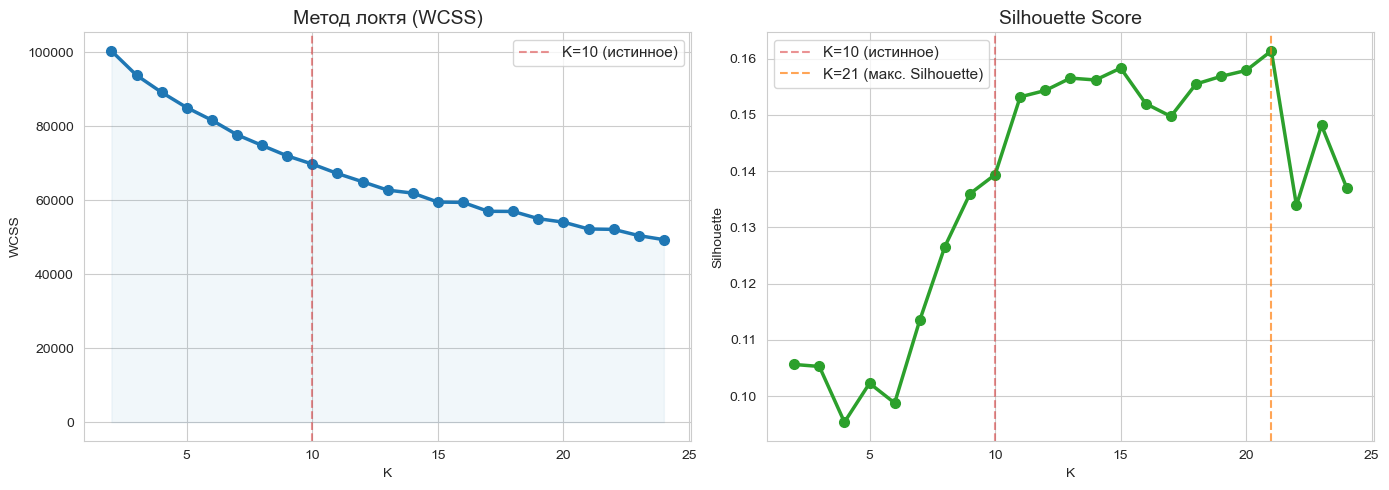

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Метод локтя (WCSS)
axes[0].plot(K_range, wcss_vals, 'o-', color='#1F77B4', linewidth=2.5, markersize=7)
axes[0].fill_between(K_range, wcss_vals, alpha=0.06, color='#1F77B4')
axes[0].axvline(x=10, color='#D62728', linestyle='--', linewidth=1.5, alpha=0.5, label='K=10 (истинное)')
axes[0].set_title('Метод локтя (WCSS)', fontsize=14)
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS')
axes[0].legend(fontsize=11)

# Silhouette
axes[1].plot(K_range, sil_vals, 'o-', color='#2CA02C', linewidth=2.5, markersize=7)
axes[1].axvline(x=10, color='#D62728', linestyle='--', linewidth=1.5, alpha=0.5, label='K=10 (истинное)')
# Отметим максимум
best_k = list(K_range)[np.argmax(sil_vals)]
axes[1].axvline(x=best_k, color='#FF7F0E', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'K={best_k} (макс. Silhouette)')
axes[1].set_title('Silhouette Score', fontsize=14)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

### 5.1 Метрики не всегда указывают на «правильный» K

- **Метод локтя** на Digits **не показывает чёткого перегиба** — WCSS плавно убывает. Нет очевидной точки, где кривая резко меняет наклон. Это типичная ситуация для сложных данных.
- **Silhouette Score** максимален не при K=10. Это потому что некоторые цифры (например, 1 и 7, или 3 и 9) очень похожи — при K=10 кластеры перекрываются и Silhouette страдает. Больше кластеров = мельче и чище группы.

**Вывод:** метрики — это подсказка, а не абсолютная истина. В реальных задачах часто решающую роль играет:
- Экспертное знание предметной области («мы знаем, что цифр 10»)
- Визуализация (t-SNE показывает ~10 облаков)
- Практическая задача (нужна ли нам разница между 3 и 9?)

Мы всё равно возьмём **K=10**, потому что знаем, что цифр 10 — и посмотрим, как K-Means справится.


### Обучение K-Means (K=10)

Сравним два способа инициализации: случайную и K-Means++.

In [9]:
km_random = KMeans(n_clusters=10, init='random', n_init=10, random_state=42)
labels_random = km_random.fit_predict(X_scaled)

km_pp = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=42)
labels_pp = km_pp.fit_predict(X_scaled)

print("Сравнение (K=10, n_init=10):")
print(f"{'':>22} {'random':>10}  {'k-means++':>10}")
print(f"{'WCSS':>22} {km_random.inertia_:>10.1f}  {km_pp.inertia_:>10.1f}")
print(f"{'Silhouette':>22} {silhouette_score(X_scaled, labels_random):>10.4f}  {silhouette_score(X_scaled, labels_pp):>10.4f}")
print(f"{'Итераций':>22} {km_random.n_iter_:>10}  {km_pp.n_iter_:>10}")

Сравнение (K=10, n_init=10):
                           random   k-means++
                  WCSS    70552.8     69813.6
            Silhouette     0.1383      0.1394
              Итераций         14          32


### Визуализация кластеров через t-SNE

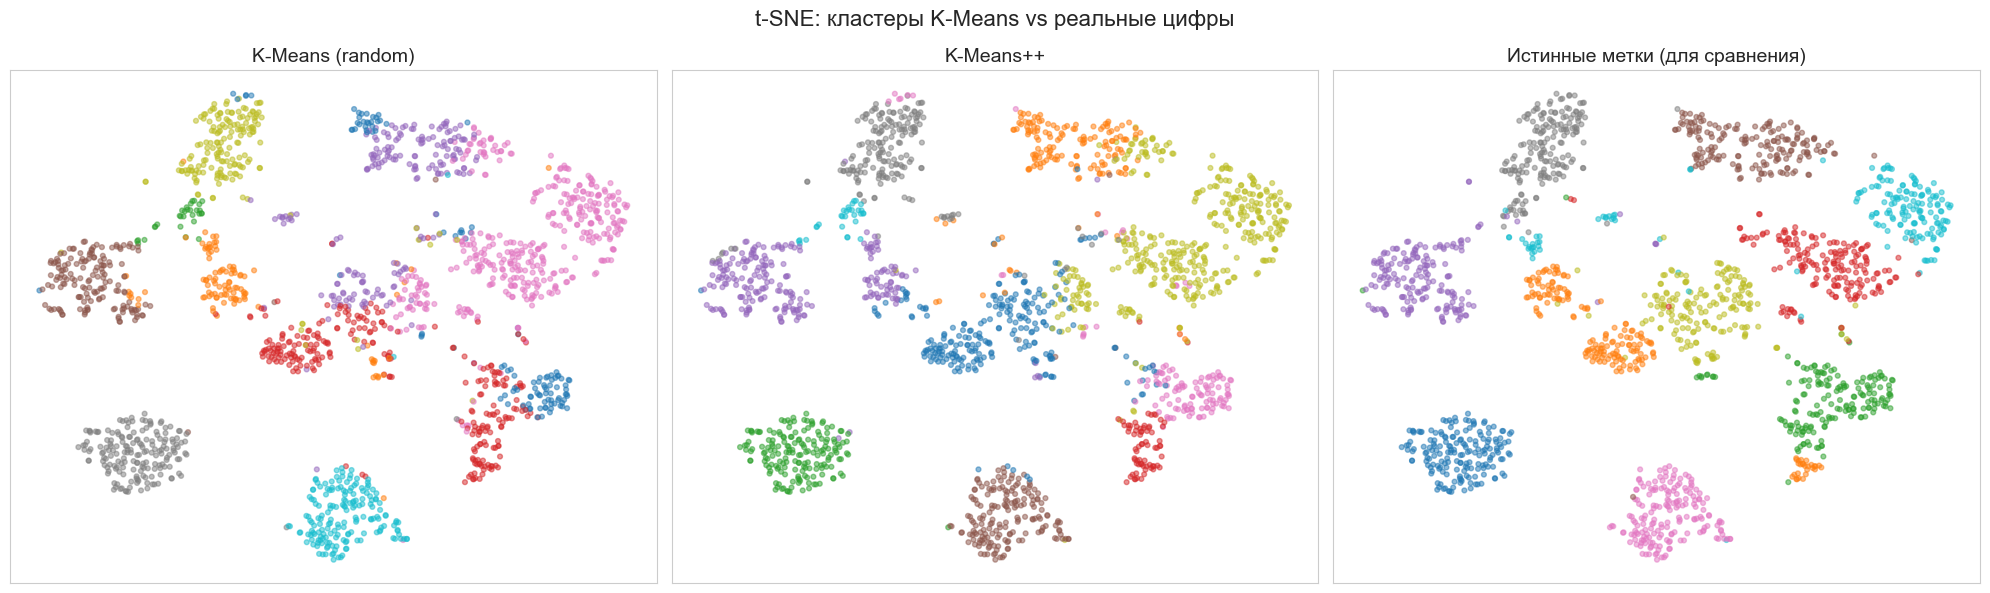

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (labels, title) in zip(axes, [
    (labels_random, 'K-Means (random)'),
    (labels_pp, 'K-Means++'),
    (y_true, 'Истинные метки (для сравнения)')
]):
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', alpha=0.5, s=12)
    ax.set_title(title, fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('t-SNE: кластеры K-Means vs реальные цифры', fontsize=16)
plt.tight_layout()
plt.show()

### Центроиды — «средние цифры»

Центроид каждого кластера — вектор из 64 чисел. Его можно показать как картинку 8×8 — это **усреднённый образ** всех точек кластера.

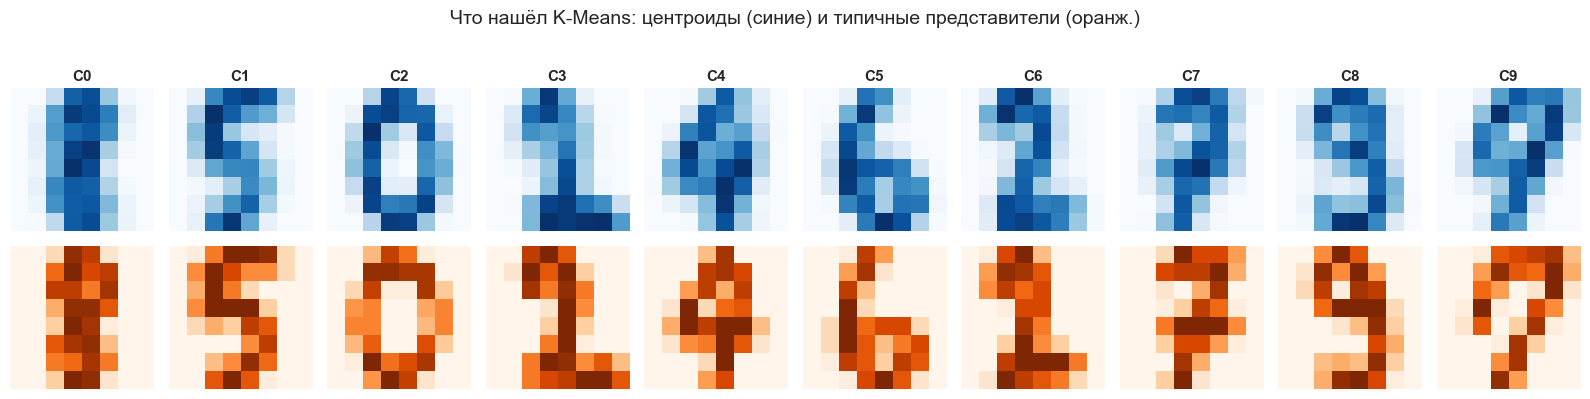

In [11]:
centroids_original = scaler.inverse_transform(km_pp.cluster_centers_)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for i in range(10):
    # Центроид
    axes[0, i].imshow(centroids_original[i].reshape(8, 8), cmap='Blues', interpolation='nearest')
    axes[0, i].set_title(f'C{i}', fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    # Ближайшая реальная точка
    members = X[labels_pp == i]
    dists = np.linalg.norm(X_scaled[labels_pp == i] - km_pp.cluster_centers_[i], axis=1)
    closest = members[np.argmin(dists)]
    axes[1, i].imshow(closest.reshape(8, 8), cmap='Oranges', interpolation='nearest')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Центроид', fontsize=10, rotation=0, labelpad=55)
axes[1, 0].set_ylabel('Ближайшая\nточка', fontsize=10, rotation=0, labelpad=55)
plt.suptitle('Что нашёл K-Means: центроиды (синие) и типичные представители (оранж.)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [12]:
# Какой реальной цифре соответствует каждый кластер?
print("Состав кластеров:\n")
for k in range(10):
    members_true = y_true[labels_pp == k]
    counts = np.bincount(members_true, minlength=10)
    dominant = np.argmax(counts)
    purity = counts[dominant] / len(members_true)
    print(f"  Кластер {k}: {len(members_true):3d} точек, "
          f"доминирует цифра {dominant} ({purity:.0%}),  состав: {dict(zip(range(10), counts)) }")

Состав кластеров:

  Кластер 0: 245 точек, доминирует цифра 1 (44%),  состав: {0: np.int64(0), 1: np.int64(107), 2: np.int64(21), 3: np.int64(7), 4: np.int64(1), 5: np.int64(1), 6: np.int64(5), 7: np.int64(0), 8: np.int64(101), 9: np.int64(2)}
  Кластер 1: 156 точек, доминирует цифра 5 (88%),  состав: {0: np.int64(0), 1: np.int64(1), 2: np.int64(0), 3: np.int64(3), 4: np.int64(2), 5: np.int64(137), 6: np.int64(0), 7: np.int64(1), 8: np.int64(7), 9: np.int64(5)}
  Кластер 2: 177 точек, доминирует цифра 0 (99%),  состав: {0: np.int64(176), 1: np.int64(0), 2: np.int64(0), 3: np.int64(0), 4: np.int64(0), 5: np.int64(0), 6: np.int64(1), 7: np.int64(0), 8: np.int64(0), 9: np.int64(0)}
  Кластер 3:  71 точек, доминирует цифра 2 (61%),  состав: {0: np.int64(0), 1: np.int64(27), 2: np.int64(43), 3: np.int64(1), 4: np.int64(0), 5: np.int64(0), 6: np.int64(0), 7: np.int64(0), 8: np.int64(0), 9: np.int64(0)}
  Кластер 4: 232 точек, доминирует цифра 4 (69%),  состав: {0: np.int64(2), 1: np.int64(46

### Стабильность: random vs K-Means++

Запустим каждый метод 50 раз с одним стартом (n_init=1) — насколько стабилен результат?

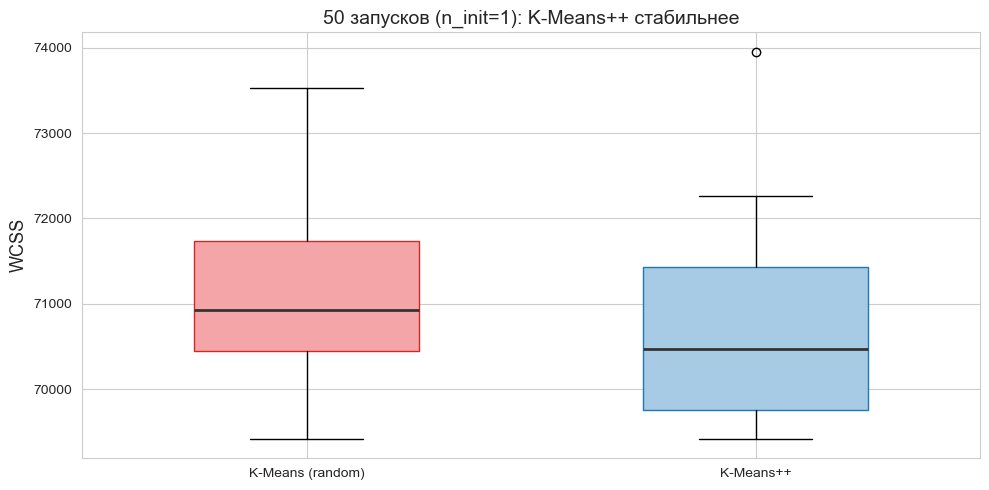

random    — mean: 71077.4,  std: 1028.3
k-means++ — mean: 70596.2,  std: 972.5


In [13]:
wcss_rand, wcss_pp = [], []

for seed in range(50):
    wcss_rand.append(KMeans(10, init='random', n_init=1, random_state=seed).fit(X_scaled).inertia_)
    wcss_pp.append(KMeans(10, init='k-means++', n_init=1, random_state=seed).fit(X_scaled).inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([wcss_rand, wcss_pp],
                labels=['K-Means (random)', 'K-Means++'],
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#F4A5A8'); bp['boxes'][0].set_edgecolor('#D62728')
bp['boxes'][1].set_facecolor('#A8CBE5'); bp['boxes'][1].set_edgecolor('#1F77B4')
for m in bp['medians']: m.set_color('#333'); m.set_linewidth(2)

ax.set_ylabel('WCSS', fontsize=13)
ax.set_title('50 запусков (n_init=1): K-Means++ стабильнее', fontsize=14)
plt.tight_layout()
plt.show()

print(f"random    — mean: {np.mean(wcss_rand):.1f},  std: {np.std(wcss_rand):.1f}")
print(f"k-means++ — mean: {np.mean(wcss_pp):.1f},  std: {np.std(wcss_pp):.1f}")

## 6. Оценка качества

### Silhouette-анализ

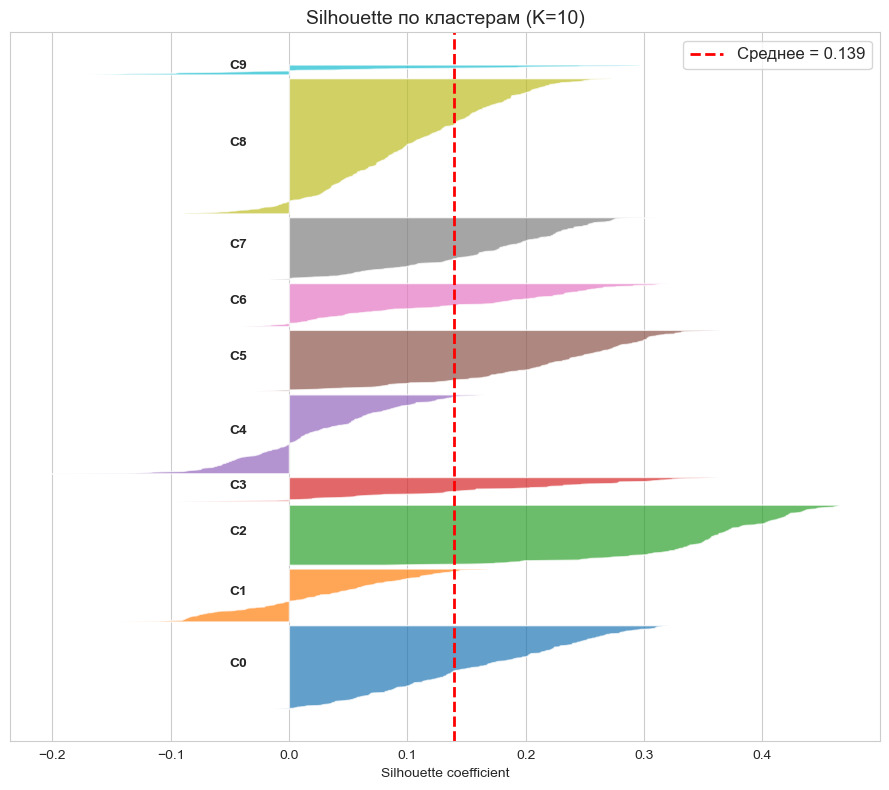

In [14]:
sil_samples = silhouette_samples(X_scaled, labels_pp)
avg_sil = silhouette_score(X_scaled, labels_pp)

fig, ax = plt.subplots(figsize=(9, 8))
y_lower = 10
cmap = plt.cm.tab10

for k in range(10):
    cluster_sil = np.sort(sil_samples[labels_pp == k])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=cmap(k / 10), alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_sil), f'C{k}',
            fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', linewidth=2,
           label=f'Среднее = {avg_sil:.3f}')
ax.set_title('Silhouette по кластерам (K=10)', fontsize=14)
ax.set_xlabel('Silhouette coefficient')
ax.set_yticks([])
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Совпадение кластеров с реальными цифрами

K-Means не видел меток. Но мы их знаем — давайте проверим.

> В реальных задачах меток обычно нет — это **учебная** проверка.

In [15]:
# Сопоставляем метки кластеров с реальными цифрами (Hungarian algorithm)
cm = confusion_matrix(y_true, labels_pp)
row_ind, col_ind = linear_sum_assignment(-cm)

labels_matched = np.zeros_like(labels_pp)
for true_label, cluster_label in zip(row_ind, col_ind):
    labels_matched[labels_pp == cluster_label] = true_label

accuracy = np.mean(labels_matched == y_true)
print(f"Accuracy (после сопоставления меток): {accuracy:.1%}")

Accuracy (после сопоставления меток): 66.3%


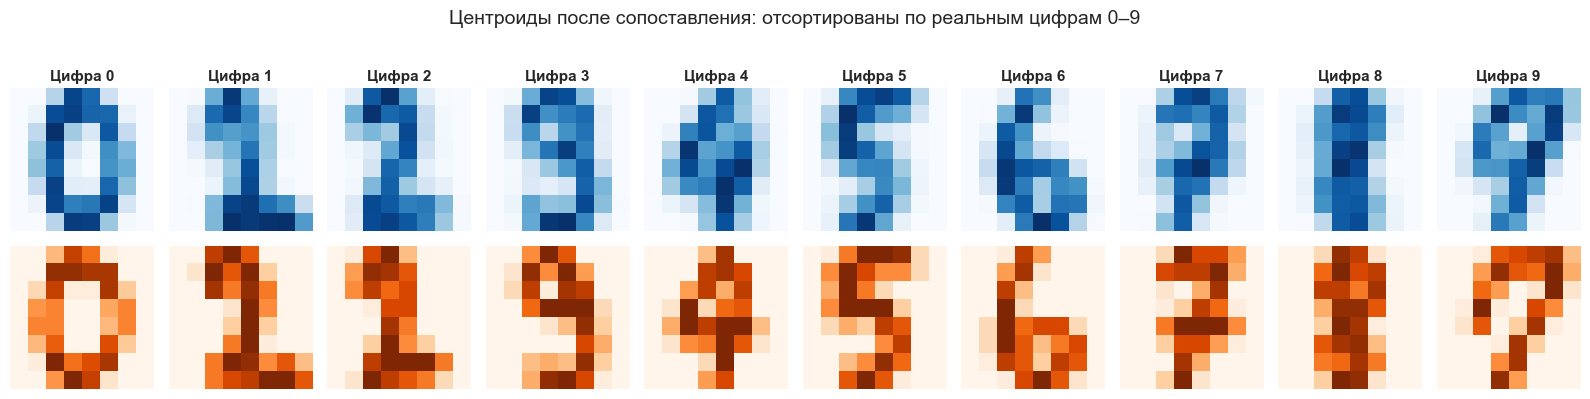

In [16]:
# Центроиды после сопоставления меток
# col_ind[i] — номер кластера, который соответствует цифре i
centroids_original = scaler.inverse_transform(km_pp.cluster_centers_)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for digit in range(10):
    cluster_idx = col_ind[digit]  # какой кластер соответствует этой цифре

    # Центроид
    axes[0, digit].imshow(centroids_original[cluster_idx].reshape(8, 8),
                          cmap='Blues', interpolation='nearest')
    axes[0, digit].set_title(f'Цифра {digit}', fontsize=11, fontweight='bold')
    axes[0, digit].axis('off')

    # Ближайшая реальная точка
    members = X[labels_pp == cluster_idx]
    dists = np.linalg.norm(X_scaled[labels_pp == cluster_idx] - km_pp.cluster_centers_[cluster_idx], axis=1)
    closest = members[np.argmin(dists)]
    axes[1, digit].imshow(closest.reshape(8, 8), cmap='Oranges', interpolation='nearest')
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel('Центроид', fontsize=10, rotation=0, labelpad=55)
axes[1, 0].set_ylabel('Ближайшая\nточка', fontsize=10, rotation=0, labelpad=55)
plt.suptitle('Центроиды после сопоставления: отсортированы по реальным цифрам 0–9', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

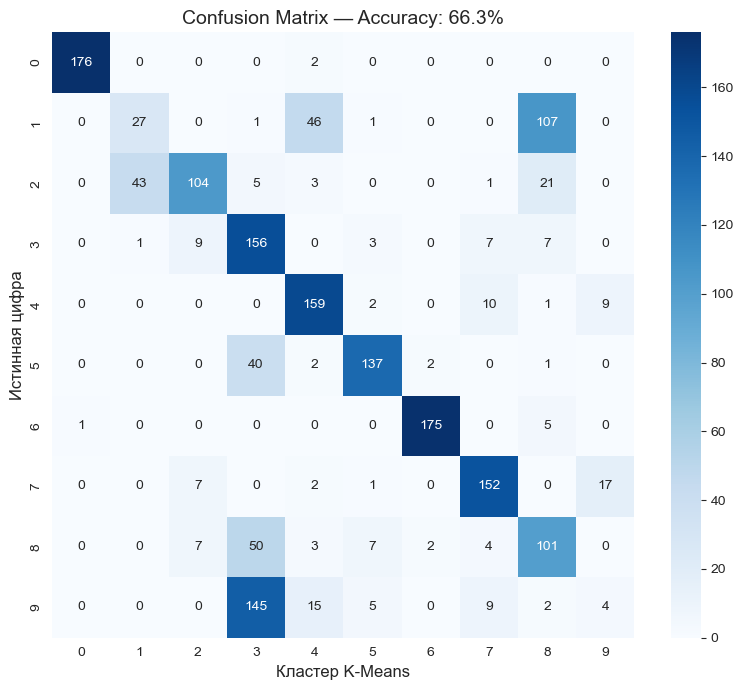


Топ-5 путаниц (истинная → предсказанная):
  Цифра 9 - Цифра 3: 145 ошибок
  Цифра 1 - Цифра 8: 107 ошибок
  Цифра 8 - Цифра 3: 50 ошибок
  Цифра 1 - Цифра 4: 46 ошибок
  Цифра 2 - Цифра 1: 43 ошибок


In [17]:
# Confusion matrix
cm_matched = confusion_matrix(y_true, labels_matched)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_matched, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Кластер K-Means', fontsize=12)
ax.set_ylabel('Истинная цифра', fontsize=12)
ax.set_title(f'Confusion Matrix — Accuracy: {accuracy:.1%}', fontsize=14)
plt.tight_layout()
plt.show()

# Какие цифры путаются?
errors = cm_matched.copy()
np.fill_diagonal(errors, 0)
print("\nТоп-5 путаниц (истинная → предсказанная):")
for _ in range(5):
    i, j = np.unravel_index(errors.argmax(), errors.shape)
    print(f"  Цифра {i} - Цифра {j}: {errors[i, j]} ошибок")
    errors[i, j] = 0

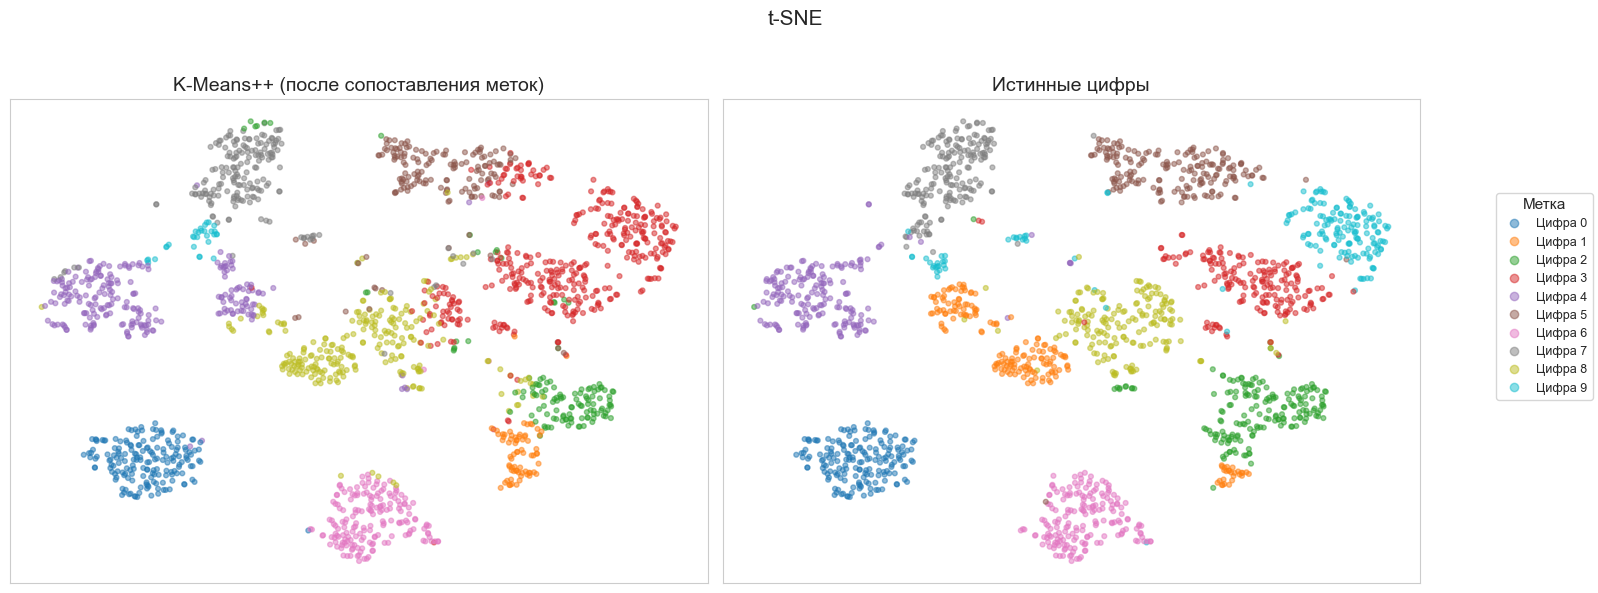

In [18]:
# t-SNE с сопоставленными метками (цифры вместо номеров кластеров)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means (после сопоставления)
sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_matched,
                       cmap='tab10', alpha=0.5, s=12, vmin=0, vmax=9)
axes[0].set_title('K-Means++ (после сопоставления меток)', fontsize=14)
axes[0].set_xticks([]); axes[0].set_yticks([])

# Истинные метки
sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true,
                       cmap='tab10', alpha=0.5, s=12, vmin=0, vmax=9)
axes[1].set_title('Истинные цифры', fontsize=14)
axes[1].set_xticks([]); axes[1].set_yticks([])

# Общая легенда
handles, labels = sc2.legend_elements()
fig.legend(handles, [f'Цифра {i}' for i in range(10)],
           loc='center right', title='Метка', fontsize=9,
           title_fontsize=11, ncol=1)

plt.suptitle('t-SNE', fontsize=15)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

### Анализ ошибок

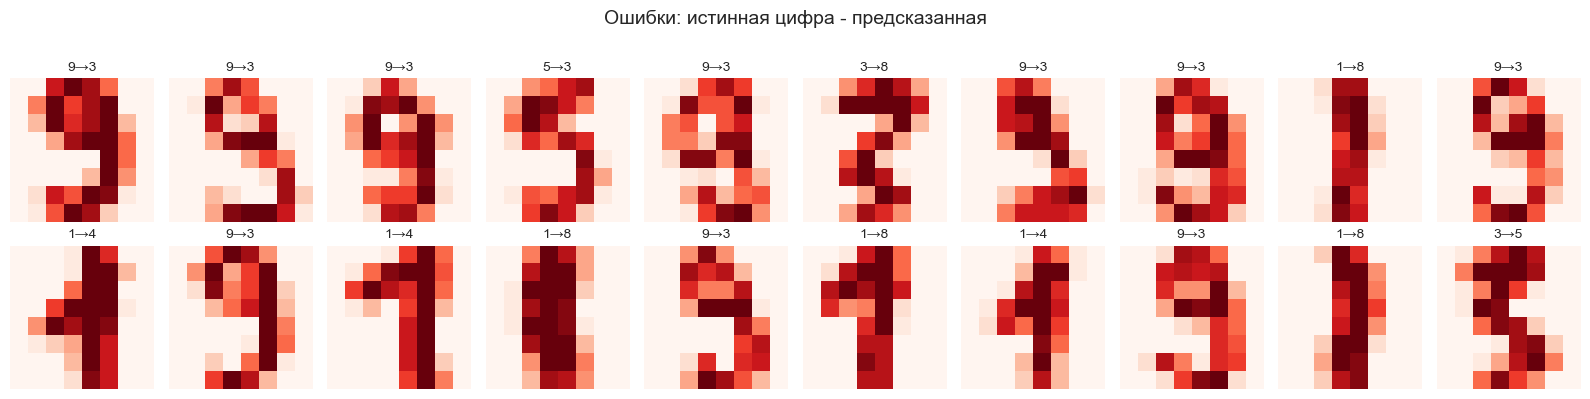

Всего ошибок: 606 из 1797 (33.7%)


In [19]:
errors_mask = labels_matched != y_true
X_errors = X[errors_mask]
y_errors_true = y_true[errors_mask]
y_errors_pred = labels_matched[errors_mask]

n_show = min(20, len(X_errors))
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

rng = np.random.RandomState(42)
idxs = rng.choice(len(X_errors), n_show, replace=False)

for i, idx in enumerate(idxs):
    row, col = divmod(i, 10)
    axes[row, col].imshow(X_errors[idx].reshape(8, 8), cmap='Reds', interpolation='nearest')
    axes[row, col].set_title(f'{y_errors_true[idx]}→{y_errors_pred[idx]}', fontsize=10)
    axes[row, col].axis('off')

plt.suptitle('Ошибки: истинная цифра - предсказанная', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Всего ошибок: {errors_mask.sum()} из {len(y_true)} ({errors_mask.mean():.1%})")